# WAVE analytical-verification figure

This notebook creates the main-paper WAVE figure from already completed lake-at-rest and Thacker simulations. It does not launch WAVE, so stylistic revisions remain independent of the numerical runs.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('WAVE', 'Paper_figures')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/WAVE/Paper_figures')

In [3]:
case.run('make_wave_verification_figures.py')


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/WAVE/Paper_figures/make_wave_verification_figures.py


{
  "figure": "wave_analytical_verification",
  "lake_at_rest": {
    "source": "/Users/cmgotelli/Desktop/AVAC-QGIS/validation/WAVE/07_baines_flow_over_bump/results/wave_lake_at_rest_error.csv",
    "maximum_Linf_eta_m": 0.0006366061298825887,
    "maximum_L2_eta_m": 6.108771603151664e-05
  },
  "thacker": {
    "source": "/Users/cmgotelli/Desktop/AVAC-QGIS/validation/WAVE/04_thacker_planar_paraboloid/results/wave_vs_swashes.csv",
    "time_s": 13.457104,
    "periods": 3,
    "rmse_centerline_depth_m": 0.0012718768820814185,
    "maximum_centerline_depth_error_m": 0.002835532043009889
  }
}


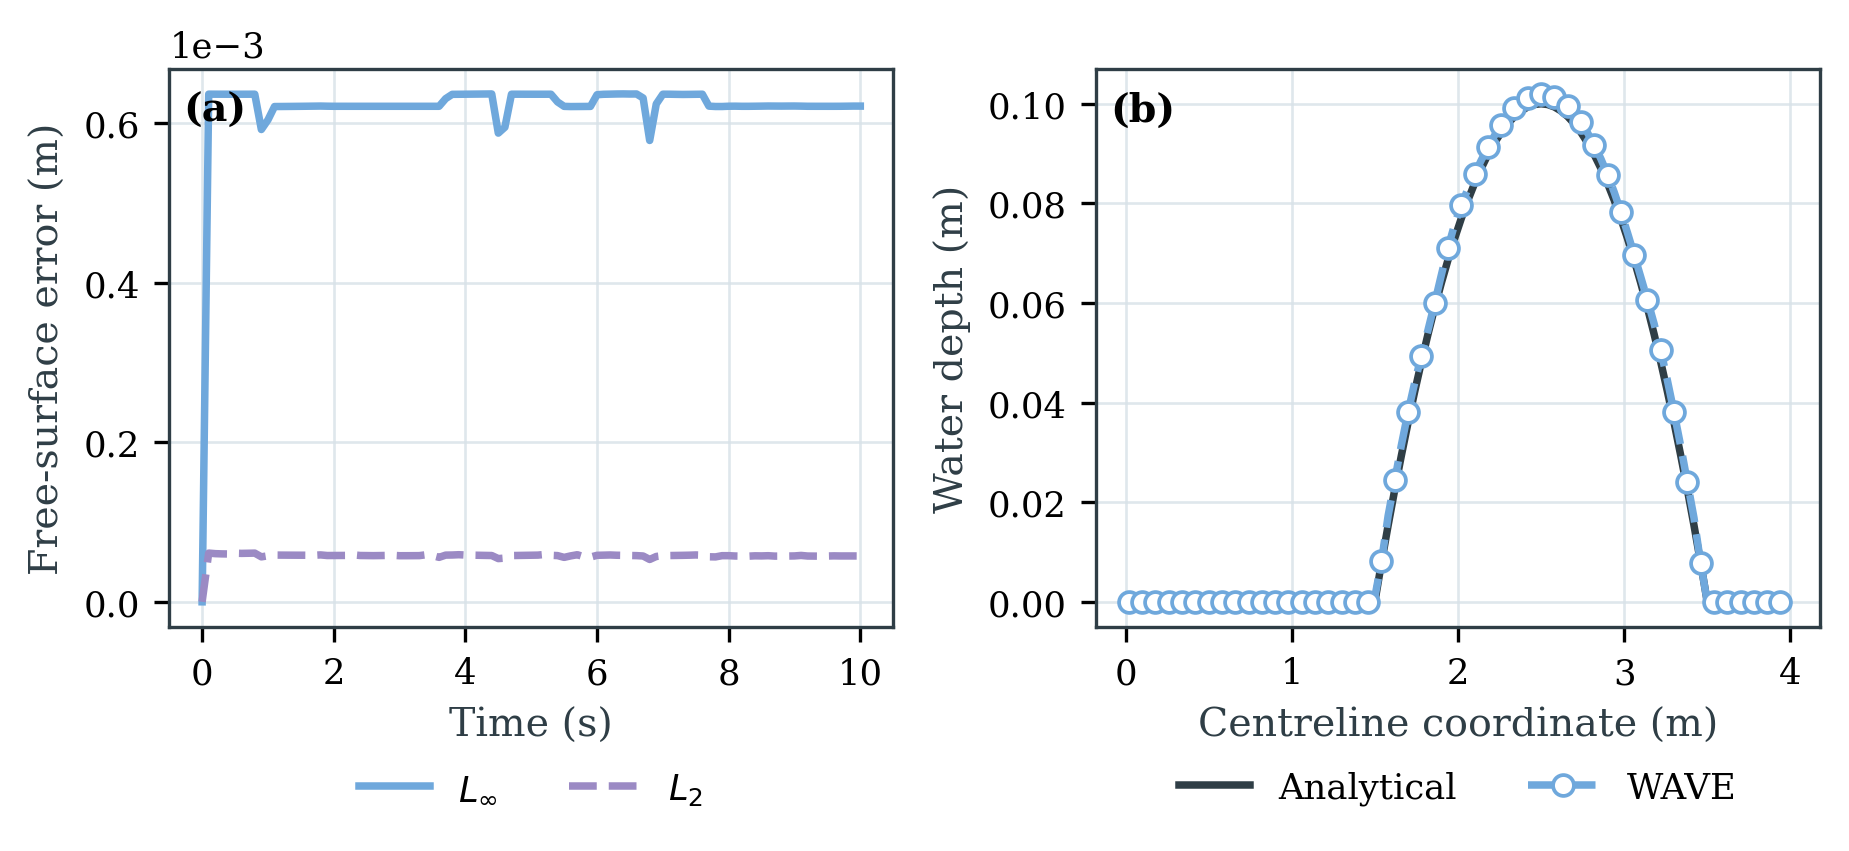

In [4]:
case.show('../../../docs/article/figures/wave_analytical_verification.png')
